# 🌍 Remote Work e Resilienza Economica in Europa
**Corso:** Internet and Network Economics — LUISS

---

### File di input necessari (nella stessa cartella del notebook):
| File | Contenuto |
|------|-----------|
| `occupations_workathome.csv` | Dingel & Neiman: occupazioni remotizzabili |
| `combined_isco_gdp.json` | Eurostat: occupazione ISCO + PIL |
| `une_rt_a_unemployment.csv` | Eurostat: tasso di disoccupazione |
| `nama_10_lp_productivity.csv` | Eurostat: produttività del lavoro |

### Output:
- `final_dataset.csv`

---
## 📦 Blocco 0 — Import delle librerie

In [76]:
import pandas as pd   # per lavorare con tabelle (DataFrame)
import numpy as np    # per calcoli numerici
import json           # per leggere file .json
import io             # per convertire testo in file leggibili da pandas

print('Librerie caricate correttamente!')

Librerie caricate correttamente!


---
## ⚙️ Configurazione generale
Definiamo qui i dizionari e le liste che useremo in tutto il notebook.

In [77]:
# Lista dei 27 paesi UE (codici ISO a 2 lettere)
EU27 = [
    'AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES',
    'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT',
    'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK'
]

# Dizionario: codice ISO → nome completo del paese
NOMI_PAESI = {
    'AT': 'Austria',     'BE': 'Belgium',     'BG': 'Bulgaria',
    'CY': 'Cyprus',      'CZ': 'Czechia',     'DE': 'Germany',
    'DK': 'Denmark',     'EE': 'Estonia',     'EL': 'Greece',
    'ES': 'Spain',       'FI': 'Finland',     'FR': 'France',
    'HR': 'Croatia',     'HU': 'Hungary',     'IE': 'Ireland',
    'IT': 'Italy',       'LT': 'Lithuania',   'LU': 'Luxembourg',
    'LV': 'Latvia',      'MT': 'Malta',       'NL': 'Netherlands',
    'PL': 'Poland',      'PT': 'Portugal',    'RO': 'Romania',
    'SE': 'Sweden',      'SI': 'Slovenia',    'SK': 'Slovakia'
}

# Dizionario: codice ISO → macro-area geografica
REGIONI = {
    'AT': 'Nord/Ovest', 'BE': 'Nord/Ovest', 'DE': 'Nord/Ovest',
    'DK': 'Nord/Ovest', 'FI': 'Nord/Ovest', 'FR': 'Nord/Ovest',
    'IE': 'Nord/Ovest', 'LU': 'Nord/Ovest', 'NL': 'Nord/Ovest',
    'SE': 'Nord/Ovest',
    'CY': 'Sud', 'EL': 'Sud', 'ES': 'Sud', 'HR': 'Sud',
    'IT': 'Sud', 'MT': 'Sud', 'PT': 'Sud', 'SI': 'Sud',
    'BG': 'Est', 'CZ': 'Est', 'EE': 'Est', 'HU': 'Est',
    'LT': 'Est', 'LV': 'Est', 'PL': 'Est', 'RO': 'Est', 'SK': 'Est'
}

# Tabella di conversione: gruppo SOC (USA) → gruppo ISCO (Europa)
# Serve per tradurre i dati americani di Dingel & Neiman nel formato europeo
SOC_A_ISCO = {
    11: 1, 19: 1,
    13: 2, 15: 2, 17: 2, 21: 2,
    23: 3, 25: 3, 27: 3, 29: 3,
    43: 4,
    35: 5, 37: 5, 39: 5,
    45: 6,
    47: 7, 49: 7,
    51: 8,
    53: 9, 55: 9
}

print('Configurazione completata!')

Configurazione completata!


---
## 📂 Blocco 1 — Caricamento dei file
Leggiamo i 4 file di input che contengono i dati grezzi.

In [78]:
# File 1: dataset Dingel & Neiman
df_dn = pd.read_csv('occupations_workathome.csv')
print(f'Dingel-Neiman: {len(df_dn)} righe')

# File 2: dati Eurostat su occupazione ISCO e PIL, salvati insieme in un file JSON
with open('combined_isco_gdp_2017_2023.json') as f:
    combined = json.load(f)

df_isco_raw = pd.read_csv(io.StringIO(combined['isco']))
df_gdp_raw  = pd.read_csv(io.StringIO(combined['gdp']))
print(f'Occupazione ISCO: {len(df_isco_raw)} righe')
print(f'PIL:              {len(df_gdp_raw)} righe')

# File 3: tasso di disoccupazione (Eurostat)
df_unemp_raw = pd.read_csv('une_rt_a_unemployment.csv')
print(f'Disoccupazione:   {len(df_unemp_raw)} righe')

# File 4: produttività del lavoro (Eurostat)
df_prod_raw = pd.read_csv('nama_10_lp_productivity.csv')
print(f'Produttività:     {len(df_prod_raw)} righe')

Dingel-Neiman: 968 righe
Occupazione ISCO: 1701 righe
PIL:              189 righe
Disoccupazione:   37581 righe
Produttività:     63506 righe


---
## 📊 Blocco 2 — Calcolo dell'Indice di Remotizzabilità

**Idea di base:**
Ogni paese ha una certa quota di lavoratori per ogni gruppo ISCO (es. 10% sono dirigenti, 20% tecnici, ecc.).
Ogni gruppo ISCO ha una percentuale di lavori che possono essere fatti da remoto (da Dingel & Neiman).

**Indice finale** = somma di (quota_gruppo × remotizzabilità_del_gruppo)

> Esempio: se il 30% dei lavoratori è ISCO 2 (70% remotizzabile) → contributo = 0.30 × 0.70 = 0.21

In [79]:
# STEP 2A: Convertiamo il codice SOC americano (es. '11-1011.00') in gruppo ISCO
# Prendiamo solo i primi 2 caratteri (es. '11') e li mappiamo nella tabella SOC_A_ISCO
df_dn['soc2']       = df_dn['onetsoccode'].str[:2].astype(int)
df_dn['isco_major'] = df_dn['soc2'].map(SOC_A_ISCO)

# Rimuoviamo le righe senza corrispondenza ISCO (NaN)
df_dn = df_dn.dropna(subset=['isco_major'])

# Righe prima della pulizia: 968
print(f'Righe dopo la pulizia: {len(df_dn)}')
df_dn[['onetsoccode', 'soc2', 'isco_major', 'teleworkable']].head()

Righe dopo la pulizia: 897


,onetsoccode,soc2,isco_major,teleworkable
0,11-1011.00,11,1.0,1
1,11-1011.03,11,1.0,1
2,11-1021.00,11,1.0,1
3,11-2011.00,11,1.0,1
4,11-2021.00,11,1.0,1


In [80]:
# STEP 2B: Per ogni gruppo ISCO, calcoliamo la % media di lavori remotizzabili
# groupby raggruppa le righe per gruppo ISCO, mean() calcola la media di 'teleworkable'
isco_telework = df_dn.groupby('isco_major')['teleworkable'].mean()

print('Quota remotizzabile per gruppo ISCO:')
for gruppo, quota in isco_telework.items():
    print(f'  ISCO {int(gruppo)}: {quota:.1%}') # .1% serve a mettere il numero in percentuale pulita (es. 83.377777% --> 83.4%)

Quota remotizzabile per gruppo ISCO:
  ISCO 1: 63.8%
  ISCO 2: 66.5%
  ISCO 3: 50.0%
  ISCO 4: 60.3%
  ISCO 5: 15.8%
  ISCO 6: 5.9%
  ISCO 7: 1.7%
  ISCO 8: 4.5%
  ISCO 9: 5.7%


In [81]:
# STEP 2C: Pulizia del dataset occupazione ISCO (Eurostat)

display(df_isco_raw)
display(df_gdp_raw)

df_isco = df_isco_raw[['geo', 'TIME_PERIOD', 'isco08', 'OBS_VALUE']].copy()
df_isco = df_isco.dropna(subset=['OBS_VALUE'])               # rimuoviamo righe senza dati
df_isco = df_isco[df_isco['geo'].isin(EU27)]                 # teniamo solo i 27 paesi UE

# Convertiamo il codice Eurostat (es. 'OC1') in numero intero (1)
df_isco['isco_major'] = df_isco['isco08'].str.replace('OC', '').astype(int)
df_isco = df_isco.rename(columns={'OBS_VALUE': 'occupati_migliaia'})

print(f'Righe dataset ISCO pulito: {len(df_isco)}')
print(df_isco.head())

,DATAFLOW,LAST UPDATE,freq,age,sex,nace_r2,isco08,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC1,THS_PER,AT,2017,201.6,NaN,NaN
1,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC2,THS_PER,AT,2017,732.0,NaN,NaN
2,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC3,THS_PER,AT,2017,790.4,NaN,NaN
3,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC4,THS_PER,AT,2017,395.2,NaN,NaN
4,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC5,THS_PER,AT,2017,720.2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1696,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC5,THS_PER,SK,2023,440.7,NaN,NaN
1697,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC6,THS_PER,SK,2023,24.6,NaN,NaN
1698,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC7,THS_PER,SK,2023,370.4,NaN,NaN
1699,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC8,THS_PER,SK,2023,314.6,NaN,NaN


,DATAFLOW,LAST UPDATE,freq,unit,na_item,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,AT,2017,323842.9,NaN,NaN
1,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,AT,2018,331887.9,NaN,NaN
2,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,AT,2019,337712.4,NaN,NaN
3,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,AT,2020,316374.9,NaN,NaN
4,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,AT,2021,331950.3,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
184,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,SK,2019,86935.4,NaN,NaN
185,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,SK,2020,84687.7,NaN,NaN
186,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,SK,2021,89477.5,NaN,NaN
187,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,SK,2022,89964.8,NaN,NaN


Righe dataset ISCO pulito: 1701
  geo  TIME_PERIOD isco08  occupati_migliaia  isco_major
0  AT         2017    OC1              201.6           1
1  AT         2017    OC2              732.0           2
2  AT         2017    OC3              790.4           3
3  AT         2017    OC4              395.2           4
4  AT         2017    OC5              720.2           5


In [82]:
# STEP 2D: Calcoliamo la quota di ogni gruppo ISCO rispetto al totale nazionale
# Prima calcoliamo il totale degli occupati per (paese, anno)
totale_per_paese = df_isco.groupby(['geo', 'TIME_PERIOD'])['occupati_migliaia'].sum().reset_index()
totale_per_paese = totale_per_paese.rename(columns={'occupati_migliaia': 'totale_occupati'})

# Uniamo il totale al dataset originale e calcoliamo la quota
df_isco = df_isco.merge(totale_per_paese, on=['geo', 'TIME_PERIOD'])
df_isco['quota_gruppo'] = df_isco['occupati_migliaia'] / df_isco['totale_occupati']

df_isco[['geo', 'TIME_PERIOD', 'isco_major', 'occupati_migliaia', 'totale_occupati', 'quota_gruppo']].head()

,geo,TIME_PERIOD,isco_major,occupati_migliaia,totale_occupati,quota_gruppo
0,AT,2017,1,201.6,4038.3,0.049922
1,AT,2017,2,732.0,4038.3,0.181264
2,AT,2017,3,790.4,4038.3,0.195726
3,AT,2017,4,395.2,4038.3,0.097863
4,AT,2017,5,720.2,4038.3,0.178342


In [83]:
# STEP 2E: Calcoliamo il contributo di ogni gruppo ISCO all'indice finale
# contributo = quota_gruppo × remotizzabilità di quel gruppo ISCO
df_isco['contributo_remote'] = df_isco['quota_gruppo'] * df_isco['isco_major'].map(isco_telework)

# Sommiamo i contributi per (paese, anno) → indice di remotizzabilità finale
indice_remotiz = df_isco.groupby(['geo', 'TIME_PERIOD'])['contributo_remote'].sum().reset_index()
indice_remotiz = indice_remotiz.rename(columns={'contributo_remote': 'remotizability_index'})

print(f'Indice calcolato: {indice_remotiz["geo"].nunique()} paesi × {indice_remotiz["TIME_PERIOD"].nunique()} anni')
indice_remotiz.head(10)

Indice calcolato: 27 paesi × 7 anni


,geo,TIME_PERIOD,remotizability_index
0,AT,2017,0.348716
1,AT,2018,0.352014
2,AT,2019,0.353327
3,AT,2020,0.359540
4,AT,2021,0.361492
5,AT,2022,0.364168
6,AT,2023,0.371870
7,BE,2017,0.394731
8,BE,2018,0.394159
9,BE,2019,0.395345


---
## 🧹 Blocco 3 — Pulizia dei dati Eurostat
Filtriamo e rinominiamo le colonne per PIL, disoccupazione e produttività.

In [84]:
# --- PIL reale ---
df_gdp = df_gdp_raw[['geo', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df_gdp = df_gdp.dropna()                              # rimuoviamo valori mancanti
df_gdp = df_gdp[df_gdp['geo'].isin(EU27)]             # solo paesi EU27
df_gdp = df_gdp.rename(columns={'OBS_VALUE': 'pil_reale_meur'})
df_gdp = df_gdp.sort_values(['geo', 'TIME_PERIOD'])   # ordiniamo per paese e anno

# Crescita % del PIL rispetto all'anno precedente
# pct_change() calcola: (valore_attuale - valore_precedente) / valore_precedente
df_gdp['crescita_pil'] = df_gdp.groupby('geo')['pil_reale_meur'].pct_change() * 100

print(f'PIL: {len(df_gdp)} righe')
df_gdp.head()

PIL: 189 righe


,geo,TIME_PERIOD,pil_reale_meur,crescita_pil
0,AT,2017,323842.9,NaN
1,AT,2018,331887.9,2.484229
2,AT,2019,337712.4,1.754960
3,AT,2020,316374.9,-6.318246
4,AT,2021,331950.3,4.923083


In [85]:
# --- Tasso di disoccupazione ---
df_unemp = df_unemp_raw[df_unemp_raw['geo'].isin(EU27)].copy()
df_unemp = df_unemp[df_unemp['TIME_PERIOD'].between(2018, 2023)]
df_unemp = df_unemp[df_unemp['sex']  == 'T']        # T = totale (maschi + femmine)
df_unemp = df_unemp[df_unemp['age']  == 'Y15-74']   # fascia d'età standard
df_unemp = df_unemp[df_unemp['unit'] == 'PC_ACT']   # percentuale sulla forza lavoro
df_unemp = df_unemp[['geo', 'TIME_PERIOD', 'OBS_VALUE']]
df_unemp = df_unemp.rename(columns={'OBS_VALUE': 'tasso_disoccupazione'})

print(f'Disoccupazione: {len(df_unemp)} righe')
df_unemp.head()

Disoccupazione: 162 righe


,geo,TIME_PERIOD,tasso_disoccupazione
11897,AT,2018,5.2
11898,AT,2019,4.8
11899,AT,2020,6.0
11900,AT,2021,6.2
11901,AT,2022,4.8


In [86]:
# --- Produttività del lavoro ---
df_prod = df_prod_raw[df_prod_raw['geo'].isin(EU27)].copy()
df_prod = df_prod[df_prod['TIME_PERIOD'].between(2017, 2023)]
df_prod = df_prod[df_prod['na_item'] == 'RLPR_HW']  # produttività per ora lavorata
df_prod = df_prod[df_prod['unit']    == 'I10']       # indice, base 2010 = 100
df_prod = df_prod[['geo', 'TIME_PERIOD', 'OBS_VALUE']]
df_prod = df_prod.rename(columns={'OBS_VALUE': 'indice_produttivita'})

print(f'Produttività: {len(df_prod)} righe')
df_prod.head()

Produttività: 189 righe


,geo,TIME_PERIOD,indice_produttivita
7483,AT,2017,105.992
7484,AT,2018,106.447
7485,AT,2019,106.566
7486,AT,2020,109.486
7487,AT,2021,109.454


---
## 🔗 Blocco 4 — Unione dei dataset
Combiniamo tutti i dati in un unico DataFrame, usando `merge` sulla coppia **(paese, anno)**.

In [87]:
# Partiamo dall'indice di remotizzabilità e aggiungiamo le altre variabili
# how='left' significa: teniamo tutte le righe dell'indice,
# anche se per qualche paese/anno mancano PIL, disoccupazione ecc.
df = indice_remotiz.copy()

df = df.merge(df_gdp[['geo', 'TIME_PERIOD', 'pil_reale_meur', 'crescita_pil']],
              on=['geo', 'TIME_PERIOD'], how='left')

df = df.merge(df_unemp,
              on=['geo', 'TIME_PERIOD'], how='left')

df = df.merge(df_prod,
              on=['geo', 'TIME_PERIOD'], how='left')

# Aggiungiamo colonne descrittive utili per i grafici
df['regione']    = df['geo'].map(REGIONI)
df['nome_paese'] = df['geo'].map(NOMI_PAESI)

print(f'Dataset finale: {df.shape[0]} righe × {df.shape[1]} colonne')
print(f'Paesi: {df["geo"].nunique()} | Anni: {sorted(df["TIME_PERIOD"].unique())}')

Dataset finale: 189 righe × 9 colonne
Paesi: 27 | Anni: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [88]:
# Controlliamo quanti valori mancanti ci sono per ogni variabile principale
colonne = ['remotizability_index', 'pil_reale_meur', 'crescita_pil',
           'tasso_disoccupazione', 'indice_produttivita']

print('Valori mancanti per colonna:')
print(df[colonne].isnull().sum())

Valori mancanti per colonna:
remotizability_index     0
pil_reale_meur           0
crescita_pil            27
tasso_disoccupazione    27
indice_produttivita      0
dtype: int64


In [89]:
# Anteprima del dataset finale
df.head(10)

,geo,TIME_PERIOD,remotizability_index,pil_reale_meur,crescita_pil,tasso_disoccupazione,indice_produttivita,regione,nome_paese
0,AT,2017,0.348716,323842.9,NaN,NaN,105.992,Nord/Ovest,Austria
1,AT,2018,0.352014,331887.9,2.484229,5.2,106.447,Nord/Ovest,Austria
2,AT,2019,0.353327,337712.4,1.754960,4.8,106.566,Nord/Ovest,Austria
3,AT,2020,0.359540,316374.9,-6.318246,6.0,109.486,Nord/Ovest,Austria
4,AT,2021,0.361492,331950.3,4.923083,6.2,109.454,Nord/Ovest,Austria
5,AT,2022,0.364168,349646.5,5.330979,4.8,112.405,Nord/Ovest,Austria
6,AT,2023,0.371870,346897.4,-0.786251,5.1,110.825,Nord/Ovest,Austria
7,BE,2017,0.394731,394666.3,NaN,NaN,102.786,Nord/Ovest,Belgium
8,BE,2018,0.394159,402078.0,1.877966,6.0,102.997,Nord/Ovest,Belgium
9,BE,2019,0.395345,411900.3,2.442884,5.5,103.878,Nord/Ovest,Belgium


---
## 💾 Blocco 5 — Salvataggio
Salviamo il dataset finale in un file CSV pronto per l'analisi.

In [99]:
df.to_csv('final_dataset.csv', index=False)
print('✅ Salvato: final_dataset.csv')
print(f'   {df.shape[0]} righe × {df.shape[1]} colonne')
print('\nColonne disponibili:')
for col in df.columns:
    print(f'  - {col}')

✅ Salvato: final_dataset.csv
   189 righe × 9 colonne

Colonne disponibili:
  - geo
  - TIME_PERIOD
  - remotizability_index
  - pil_reale_meur
  - crescita_pil
  - tasso_disoccupazione
  - indice_produttivita
  - regione
  - nome_paese


In [100]:
df

,geo,TIME_PERIOD,remotizability_index,pil_reale_meur,crescita_pil,tasso_disoccupazione,indice_produttivita,regione,nome_paese
0,AT,2017,0.348716,323842.9,NaN,NaN,105.992,Nord/Ovest,Austria
1,AT,2018,0.352014,331887.9,2.484229,5.2,106.447,Nord/Ovest,Austria
2,AT,2019,0.353327,337712.4,1.754960,4.8,106.566,Nord/Ovest,Austria
3,AT,2020,0.359540,316374.9,-6.318246,6.0,109.486,Nord/Ovest,Austria
4,AT,2021,0.361492,331950.3,4.923083,6.2,109.454,Nord/Ovest,Austria
...,...,...,...,...,...,...,...,...,...
184,SK,2019,0.300308,86935.4,2.275858,5.7,119.756,Est,Slovakia
185,SK,2020,0.311039,84687.7,-2.585483,6.7,127.980,Est,Slovakia
186,SK,2021,0.323536,89477.5,5.655839,6.8,135.190,Est,Slovakia
187,SK,2022,0.324985,89964.8,0.544606,6.1,131.195,Est,Slovakia


## Blocco 6 - Fase 1: Statistiche descrittive (cami)

### punto 1.1

In [91]:
var_numeriche = ["remotizability_index", "crescita_pil", "tasso_disoccupazione", "indice_produttivita"]

print("Statistiche descrittive campione completo:")
print(df[var_numeriche].describe().round(3))

Statistiche descrittive campione completo:
       remotizability_index  crescita_pil  tasso_disoccupazione  \
count               189.000       162.000               162.000   
mean                  0.353         2.391                 6.369   
std                   0.047         4.308                 3.012   
min                   0.228       -10.940                 2.000   
25%                   0.325         0.433                 4.500   
50%                   0.349         2.463                 5.950   
75%                   0.384         5.060                 7.200   
max                   0.481        16.258                19.700   

       indice_produttivita  
count              189.000  
mean               116.220  
std                 16.046  
min                 83.774  
25%                105.882  
50%                111.816  
75%                124.887  
max                178.582  


In [92]:
print("Statistiche descrittive raggrupate per regione:")
print(df.groupby("regione")[var_numeriche].describe().round(3))


Statistiche descrittive raggrupate per regione:
           remotizability_index                                            \
                          count   mean    std    min    25%    50%    75%   
regione                                                                     
Est                        63.0  0.314  0.035  0.228  0.291  0.322  0.336   
Nord/Ovest                 70.0  0.398  0.031  0.349  0.376  0.393  0.412   
Sud                        56.0  0.340  0.021  0.309  0.325  0.333  0.351   

                  crescita_pil         ... tasso_disoccupazione        \
              max        count   mean  ...                  75%   max   
regione                                ...                              
Est         0.366         54.0  2.409  ...                6.300   8.5   
Nord/Ovest  0.481         60.0  1.857  ...                6.825   9.0   
Sud         0.389         48.0  3.038  ...               10.725  19.7   

           indice_produttivita                    

### punto 1.2

In [93]:
df_2019 = df[df["TIME_PERIOD"]== 2019].sort_values("remotizability_index", ascending= False)
df_2019

,geo,TIME_PERIOD,remotizability_index,pil_reale_meur,crescita_pil,tasso_disoccupazione,indice_produttivita,regione,nome_paese
121,LU,2019,0.461906,52367.4,2.749273,5.6,97.474,Nord/Ovest,Luxembourg
142,NL,2019,0.414104,740314.7,2.300167,4.4,103.668,Nord/Ovest,Netherlands
170,SE,2019,0.410263,448948.9,2.608237,6.9,107.529,Nord/Ovest,Sweden
9,BE,2019,0.395345,411900.3,2.442884,5.5,103.878,Nord/Ovest,Belgium
44,DK,2019,0.391548,284554.9,1.711388,5.0,112.502,Nord/Ovest,Denmark
37,DE,2019,0.379930,3051087.9,0.977735,2.9,109.981,Nord/Ovest,Germany
135,MT,2019,0.379115,11868.5,4.084997,4.1,115.890,Sud,Malta
100,IE,2019,0.376373,297083.9,4.972897,5.0,139.675,Nord/Ovest,Ireland
72,FI,2019,0.372641,204113.7,1.349733,6.8,105.292,Nord/Ovest,Finland
79,FR,2019,0.367047,2250184.8,2.027445,8.4,107.655,Nord/Ovest,France


In [94]:
print(df_2019[["nome_paese", "remotizability_index"]])

      nome_paese  remotizability_index
121   Luxembourg              0.461906
142  Netherlands              0.414104
170       Sweden              0.410263
9        Belgium              0.395345
44       Denmark              0.391548
37       Germany              0.379930
135        Malta              0.379115
100      Ireland              0.376373
72       Finland              0.372641
79        France              0.367047
177     Slovenia              0.355312
2        Austria              0.353327
51       Estonia              0.349419
23        Cyprus              0.335162
114    Lithuania              0.333571
86       Croatia              0.332276
107        Italy              0.328799
156     Portugal              0.328247
128       Latvia              0.324392
149       Poland              0.323143
65         Spain              0.317520
30       Czechia              0.316138
58        Greece              0.314165
184     Slovakia              0.300308
93       Hungary         

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

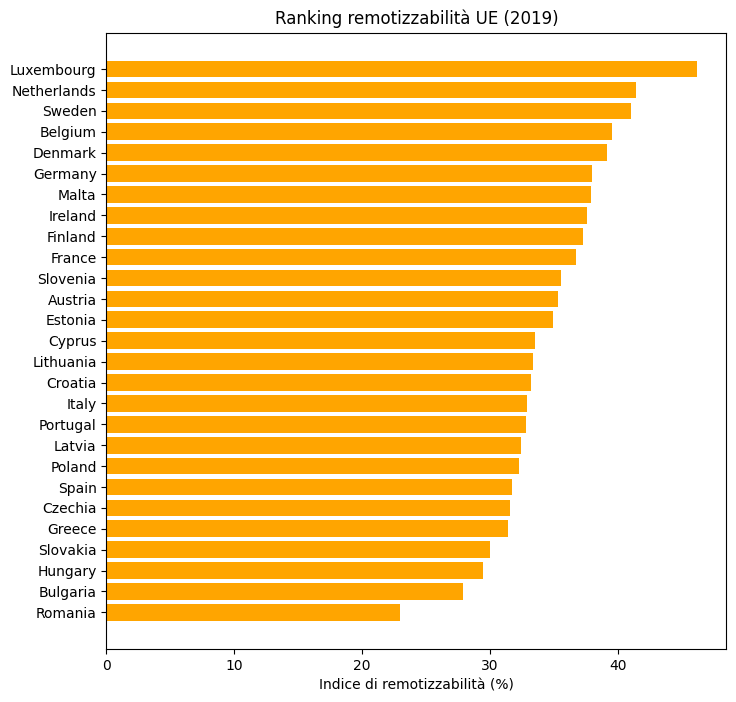

In [96]:
df_2019_sorted = df_2019.sort_values("remotizability_index")

plt.figure(figsize=(8, 8))
plt.barh(df_2019_sorted["nome_paese"], df_2019_sorted["remotizability_index"]* 100, color = "orange")
plt.xlabel("Indice di remotizzabilità (%)")
plt.title("Ranking remotizzabilità UE (2019)")
plt.show()

### come possiamo vedere dal grafico il primo paese più remotizzabile è il Lussemburgo mentre il meno remotizzabile è la Romania. L'indice del primo è circa il doppio dell'indice dell'ultimo. 

### punto 1.3

In [97]:
corr = df[var_numeriche].corr().round(3)
print(corr)

                      remotizability_index  crescita_pil  \
remotizability_index                 1.000        -0.035   
crescita_pil                        -0.035         1.000   
tasso_disoccupazione                -0.168        -0.111   
indice_produttivita                 -0.281         0.234   

                      tasso_disoccupazione  indice_produttivita  
remotizability_index                -0.168               -0.281  
crescita_pil                        -0.111                0.234  
tasso_disoccupazione                 1.000               -0.387  
indice_produttivita                 -0.387                1.000  


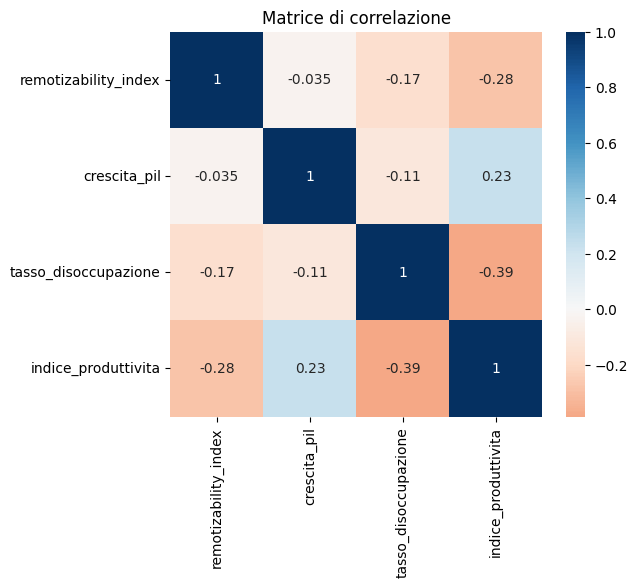

In [98]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="RdBu", center=0)
plt.title("Matrice di correlazione")
plt.show()

### remotizability_index --> crescita_pil: r = -0.003
Correlazione praticamente zero. 
L'indice di remotizzabilità non ha nessuna relazione lineare con la crescita del PIL. Interessante perché suggerisce che essere più remotizzabile non si traduce automaticamente in crescita economica.

### remotizability_index --> tasso_disoccupazione: r = -0.17
Correlazione negativa debole. 
I paesi più remotizzabili tendono ad avere leggermente meno disoccupazione, ma il legame è molto tenue.

### remotizability_index --> indice_produttivita: r = -0.30
Correlazione negativa moderata. 
I paesi con economie più orientate ai servizi (Nord/Ovest) hanno più lavori remotizzabili, ma anche produttività più bassa rispetto ai paesi dell'Est che invece puntano sull'industria manifatturiera, settore ad alta produttività ma difficilmente remotizzabile

### crescita_pil -->  indice_produttivita: r = 0.23
Correlazione positiva debole. 
Chi cresce di più tende ad avere produttività leggermente più alta.

### tasso_disoccupazione -->  indice_produttivita: r = -0.39
La correlazione più forte in assoluto. 
I paesi con più disoccupazione hanno produttività più bassa. 